In [2]:
# 데이터 가져오기
import pandas as pd

df = pd.read_csv('WA_Marketing-Campaign.csv')
df.head()

print(df.describe())

         MarketID  LocationID  AgeOfStore   Promotion        week  \
count  548.000000  548.000000  548.000000  548.000000  548.000000   
mean     5.715328  479.656934    8.503650    2.029197    2.500000   
std      2.877001  287.973679    6.638345    0.810729    1.119055   
min      1.000000    1.000000    1.000000    1.000000    1.000000   
25%      3.000000  216.000000    4.000000    1.000000    1.750000   
50%      6.000000  504.000000    7.000000    2.000000    2.500000   
75%      8.000000  708.000000   12.000000    3.000000    3.250000   
max     10.000000  920.000000   28.000000    3.000000    4.000000   

       SalesInThousands  
count        548.000000  
mean          53.466204  
std           16.755216  
min           17.340000  
25%           42.545000  
50%           50.200000  
75%           60.477500  
max           99.650000  


In [3]:
# 전체 개요, 결측치 확인
df.info()

# 열별 결측치 개수 & 비율
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    '결측치_개수': missing,
    '결측치_비율(%)': missing_pct.round(2)
})
missing_summary[missing_summary['결측치_개수'] > 0].sort_values('결측치_개수', ascending=False)

print("결측치 없음")

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 33.1 KB
결측치 없음


In [4]:
# IQR 기준 이상치 확인
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"[{col}] 이상치 개수: {len(outliers)}개 ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  정상 범위: {lower:.2f} ~ {upper:.2f}")
    return outliers

numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    detect_outliers_iqr(df, col)
print()
print("* SalesInThousands 칼럼에서 이상치가 33개(6.02%) 발견되었으나 고매출일 경우를 고려하여 제거하지 않고 유지")

[MarketID] 이상치 개수: 0개 (0.00%)
  정상 범위: -4.50 ~ 15.50
[LocationID] 이상치 개수: 0개 (0.00%)
  정상 범위: -522.00 ~ 1446.00
[AgeOfStore] 이상치 개수: 12개 (2.19%)
  정상 범위: -8.00 ~ 24.00
[Promotion] 이상치 개수: 0개 (0.00%)
  정상 범위: -2.00 ~ 6.00
[week] 이상치 개수: 0개 (0.00%)
  정상 범위: -0.50 ~ 5.50
[SalesInThousands] 이상치 개수: 33개 (6.02%)
  정상 범위: 15.65 ~ 87.38

* SalesInThousands 칼럼에서 이상치가 33개(6.02%) 발견되었으나 고매출일 경우를 고려하여 제거하지 않고 유지


# 점검

### 1. 기본 확인  
|항목|	값|
|---|---|
|행 수|	548|
|각 행의 의미| 1행 당 1개 매장|
|컬럼|	MarketID, MarketSize, LocationID, AgeOfStore, Promotion, week, Sales|
|자료형|	MarketID(int), MarketSize(str), LocationID(int), AgeOfStore(int), Promotion(int), week(int), Sales(float)|
|결측치|	전 컬럼 0건|

### 2. 중복 확인
|점검 항목|	결과|
|---|---|
|완전 중복 행|	0건|
|동일 LocationID + week 조합 중복|	0건|  

→ 같은 매장이 같은 주차에 두 번 이상 등장하는 경우 없음. 매장(실험 단위)이 중복 카운트되는 문제는 없음

### 3. 배정 일관성
|점검 항목|	어긋난 케이스|
|---|---|
|동일 LocationID에 서로 다른 Promotion이 섞인 경우|	0 / 137개|
|동일 MarketID에 서로 다른 MarketSize가 섞인 경우|	0 / 10개|
|동일 LocationID가 서로 다른 MarketID에 걸친 경우|	0 / 137개|

→ 배정 어긋남에 해당하는 문제 없음. 매장 하나에 프로모션 하나만 고정 배정되어 있고, 시장 분류 체계도 일관됨

### 4. SRM (Sample Ratio Mismatch) 점검

배정이 의도한 대로 (대략 균등하게) 이뤄졌는지 카이제곱 검정으로 확인.

행(주차별 관측치) 기준:

|Promotion|	관측치 수|
|---|---|
|1|	172|
|2|	188|
|3|	188|

기대값(균등 배정 가정): 182.7
χ² = 0.9343, p = 0.6268

매장(LocationID) 기준:

|Promotion|	매장 수|
|----|----|
|1|	43|
|2|	47|
|3|	47|

χ² = 0.2336, p = 0.8898

→ 두 기준 모두 p > 0.05로, 분배에 차이가 없다는 귀무가설이 기각되지 않음, 배정 비율이 의도한 균등 분배에서 유의하게 벗어나지 않았음. SRM 문제 없음.

종합
|점검 항목|	결과|
|---|---|
|결측치|    없음 ✅|
|중복 행|	없음 ✅|
|배정 일관성|	문제 없음 ✅|

SRM	문제 없음 (p=0.63, p=0.89) ✅

### 질문과 가설
 1. 3가지 Promotion 유형에 따라 평균 매출이 다른가?  (메인 가설)  
 H0: 3가지 Promotion 유형에 따른 평균 매출은 같다  
 H1: 3가지 Promotion 유형에 따라 적어도 한 그룹의 평균 매출은 다르다

 2. Promotion의 효과가 MarketSize에 따라 달라지는가?  (시간 되면 확인해보기)  
 H0: MarketSize에 따른 Promotion의 효과 차이는 없다 (어느 시장 크기에서든 Promotion의 효과 순서는 동일하다)  
 H1: MarketSize에 따라 Promotion의 효과가 달라진다 (시장 크기에 따라 Promotion의 효과 순서가 달라진다)

## 1번 질문 가설검증
1. 성공 지표가 **비율**(전환·재접속 여부)인가, **연속형**(매출·라운드 수)인가? - 연속형  
2. 비교할 집단이 **2개**인가, **3개 이상**인가? - 3개  
3. 연속형이라면 — **정규성**과 **등분산**은 그럴듯한가? - 정규성은 성립하지 않으나 등분산성은 성립함  
-> 연속성이며 3개 이상의 집단을 비교하는것이므로 ANOVA 검정 사용

In [ ]:
# 그룹별 변수 정의

df['Promotion'].value_counts()

groups = df.groupby('Promotion')

group_1 = groups.get_group(1)
group_2 = groups.get_group(2)
group_3 = groups.get_group(3)

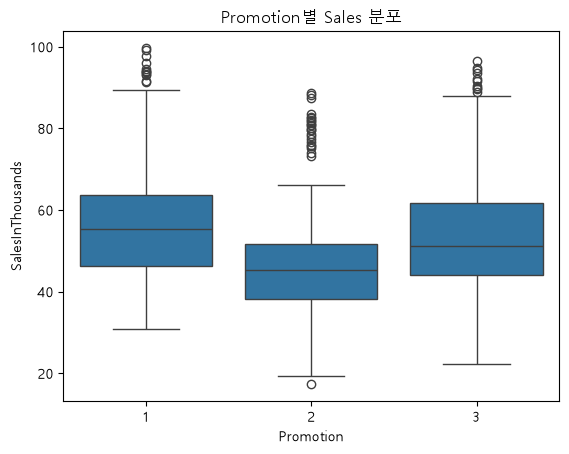

In [ ]:
# Boxplot으로 데이터 분포 확인

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지 (한글 폰트 쓰면 - 가 깨지는 경우가 있어요)
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(x='Promotion', y='SalesInThousands', data=df)
plt.title('Promotion별 Sales 분포')
plt.show()

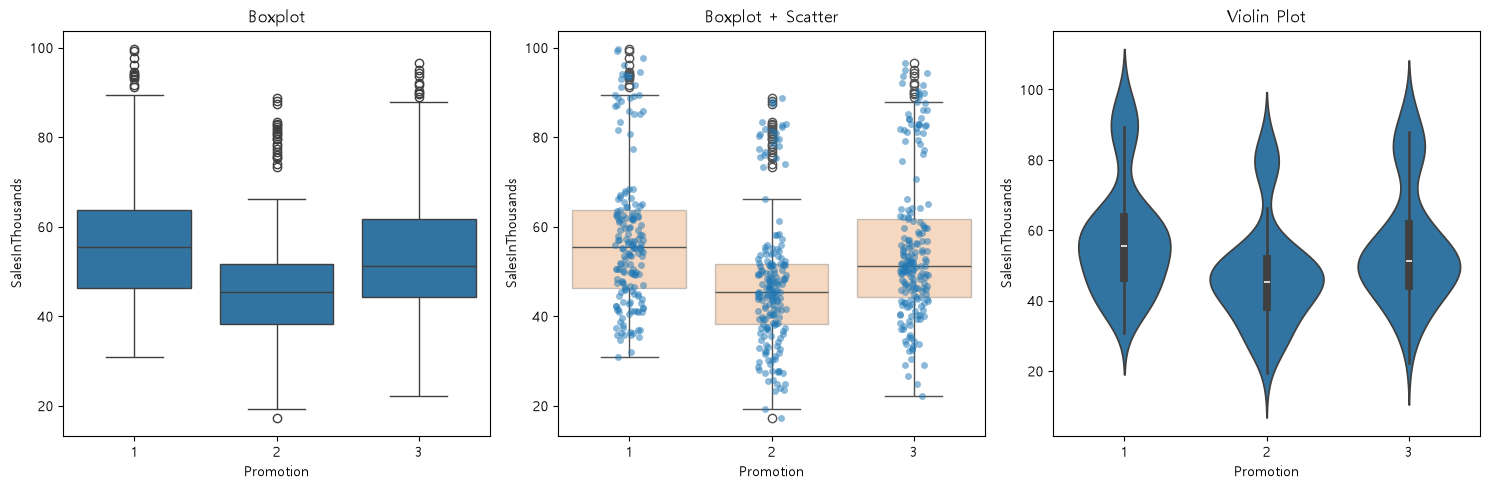

In [11]:
# Boxplot과 Stripplot, Violin plot
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# 1) Boxplot
sns.boxplot(x='Promotion', y='SalesInThousands', data=df, ax=axes[0])
axes[0].set_title('Boxplot')

# 2) Boxplot + 산점도 (개별 데이터 포인트까지 같이 보기)
sns.stripplot(x='Promotion', y='SalesInThousands', data=df, ax=axes[1], alpha=0.5, jitter=True)
sns.boxplot(x='Promotion', y='SalesInThousands', data=df, ax=axes[1], boxprops=dict(alpha=0.3))
axes[1].set_title('Boxplot + Scatter')

# 3) Violin plot (분포 모양까지 보기)
sns.violinplot(x='Promotion', y='SalesInThousands', data=df, ax=axes[2])
axes[2].set_title('Violin Plot')

plt.tight_layout()
plt.show()

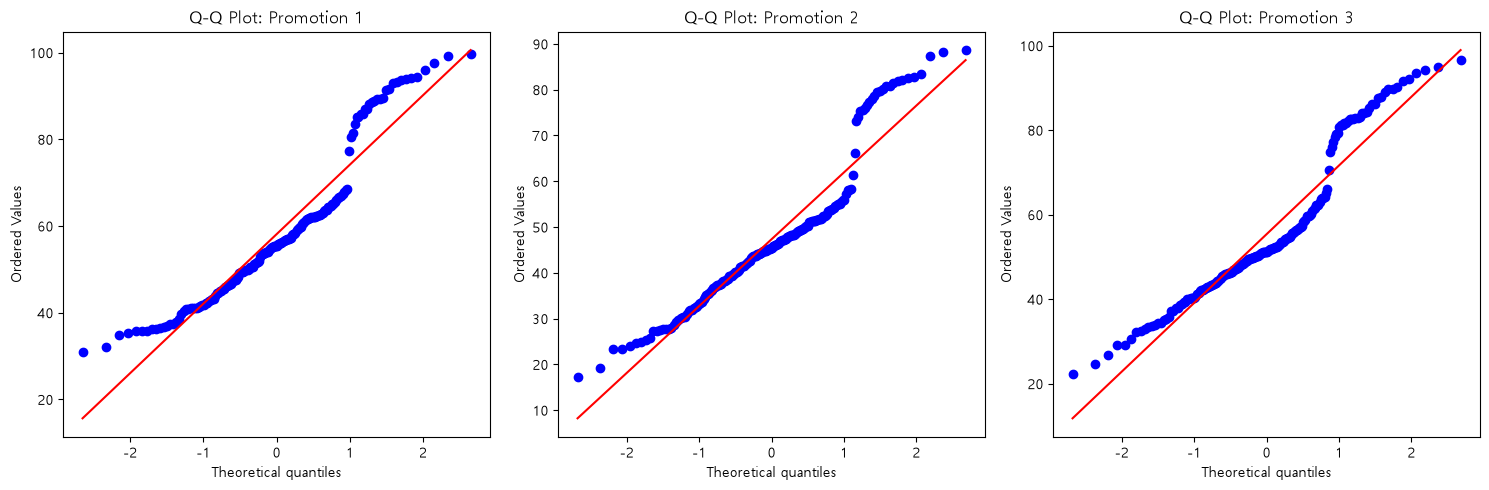

매출이 높은 영역에서 정규분포를 따르지 않는 경향이 보임


In [15]:
# QQ차트로 정규분포를 따르는지 확인
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15,5))
groups = [g1, g2, g3]
names = ['Promotion 1', 'Promotion 2', 'Promotion 3']

for ax, g, name in zip(axes, groups, names):
    stats.probplot(g, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {name}')

plt.tight_layout()
plt.show()
print("매출이 높은 영역에서 정규분포를 따르지 않는 경향이 보임")

In [13]:
#ANOVA 검정 전 정규성 & 등분산성 검정 실행
from scipy import stats

g1 = df[df['Promotion']==1]['SalesInThousands']
g2 = df[df['Promotion']==2]['SalesInThousands']
g3 = df[df['Promotion']==3]['SalesInThousands']

# 정규성 (Shapiro-Wilk)
for i, g in enumerate([g1,g2,g3], start=1):
    print(i, stats.shapiro(g))

# 등분산성 (Levene)
print(stats.levene(g1, g2, g3))
print()
print("정규성 검정(Shapiro-Wilk)의 경우 3가지 그룹 모두 p값이 0.05보다 한참 작다 -> 정규성을 따른다는 귀무가설이 기각 -> 정규분포를 따르지 않음")
print("등분산성 검정에서는 p값이 0.28로 0.05보다 큼, 분산이 같다는 귀무가설이 기각되지 못함 -> 분산이 같다")

1 ShapiroResult(statistic=np.float64(0.9152999060992891), pvalue=np.float64(1.97726450444774e-08))
2 ShapiroResult(statistic=np.float64(0.914509809064016), pvalue=np.float64(5.457099666274281e-09))
3 ShapiroResult(statistic=np.float64(0.9207683041490243), pvalue=np.float64(1.49946592611918e-08))
LeveneResult(statistic=np.float64(1.2696787527507418), pvalue=np.float64(0.2817514565692176))

정규성 검정(Shapiro-Wilk)의 경우 3가지 그룹 모두 p값이 0.05보다 한참 작다 -> 정규성을 따른다는 귀무가설이 기각 -> 정규분포를 따르지 않음
등분산성 검정에서는 p값이 0.28로 0.05보다 큼, 분산이 같다는 귀무가설이 기각되지 못함 -> 분산이 같다


In [ ]:
# 각 프로모션 타입별 LocationID
df.groupby('Promotion')['LocationID'].nunique()

Promotion
1    43
2    47
3    47
Name: LocationID, dtype: int64

In [16]:
# 각 프로모션 타입별 MarketSize 기준 매장 수

df_promogroup = df.groupby('Promotion')['MarketSize'].value_counts()
print(df_promogroup)
print()
print("Promotion 1의 표본수가 적은 건 관측 누락이나 데이터 문제가 아니라, 매장을 세 그룹에 배정하는 과정에서 발생한 자연스러운 불균형이며,")
print("SRM 검정 결과(p=0.89) 이 정도 불균형은 통계적으로 유의한 수준이 아니다. 따라서 이후의 ANOVA/Tukey 분석 결과 해석에 영향을 주지 않는다 ")

Promotion  MarketSize
1          Medium         96
           Large          56
           Small          20
2          Medium        108
           Large          64
           Small          16
3          Medium        116
           Large          48
           Small          24
Name: count, dtype: int64

Promotion 1의 표본수가 적은 건 관측 누락이나 데이터 문제가 아니라, 매장을 세 그룹에 배정하는 과정에서 발생한 자연스러운 불균형이며,
SRM 검정 결과(p=0.89) 이 정도 불균형은 통계적으로 유의한 수준이 아니다. 따라서 이후의 ANOVA/Tukey 분석 결과 해석에 영향을 주지 않는다 


In [ ]:
# One-way ANOVA 검정 실행
f_stat, p_val = stats.f_oneway(g1, g2, g3)
print(f"f통계값: {f_stat:.4f}, p값: {p_val}")


# 귀무가설(H0): Promotion 1, 2, 3의 평균 매출이 모두 같다
# 대립가설(H1): 적어도 하나는 다르다

# Kruskal-Wallis (비모수 대안, 교차검증용, 정규성 성립이 안되더라도 사용 가능)
h_stat, p_val_kw = stats.kruskal(g1, g2, g3)
print(f"h통계값: {h_stat:.4f}, p값: {p_val_kw}")

print("두 가지 검정 모두 p<0.5이므로 귀무가설을 기각한다, 3개 그룹의 평균이 적어도 하나는 다를 가능성이 있음")

f통계값: 21.9535, p값: 6.765849261408786e-10
h통계값: 53.2948, p값: 2.6741866266697816e-12
두 가지 검정 모두 p<0.5이므로 귀무가설을 기각한다, 3개 그룹의 평균이 적어도 하나는 다를 가능성이 있음


In [18]:
#Promotion 그룹 별 평균 Sales 비교

df = df.rename(columns={'SalesInThousands': 'Sales'})



summary = df.groupby('Promotion')['Sales'].agg(['count','mean','median','std','min','max']).round(2)
print(summary)
print()
print("평균 Sales는 Promotion 1에서 가장 크게 발생, 2와 3이 뒤를 따른다")

           count   mean  median    std    min    max
Promotion                                           
1            172  58.10   55.39  16.55  30.81  99.65
2            188  47.33   45.39  15.11  17.34  88.64
3            188  55.36   51.16  16.77  22.18  96.48

평균 Sales는 Promotion 1에서 가장 크게 발생, 2와 3이 뒤를 따른다


In [25]:
#점추정으로 얼마나 차이나는지 확인
means = df.groupby('Promotion')['Sales'].mean()
print(means[1] - means[2], means[1] - means[3], means[2] - means[3])
print(f"프로모션 1,2 차이: {means[1]-means[2]:.2f}")
print(f"프로모션 1,3 차이: {means[1]-means[3]:.2f}")
print(f"프로모션 2,3 차이: {means[2]-means[3]:.2f}")

10.769596734289962 2.734543542800594 -8.035053191489368
프로모션 1,2 차이: 10.77
프로모션 1,3 차이: 2.73
프로모션 2,3 차이: -8.04


In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df['Sales'], groups=df['Promotion'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


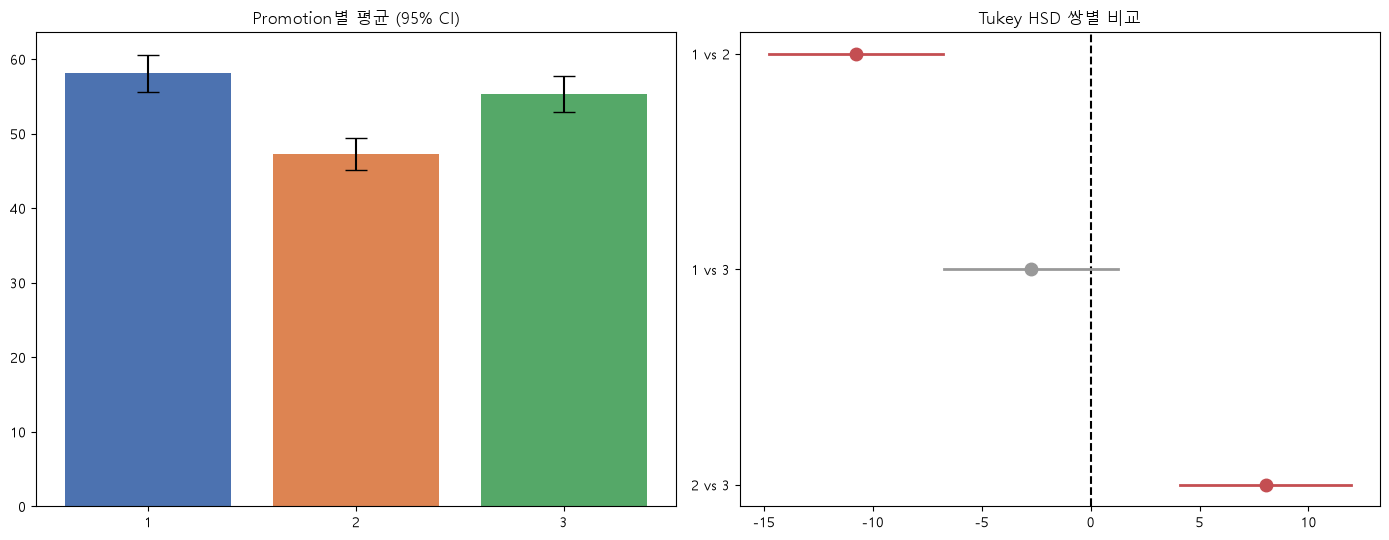

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

# 왼쪽: 그룹 평균 + CI
grouped = df.groupby('Promotion')['Sales']
means = grouped.mean()
ci95 = grouped.sem() * 1.96

axes[0].bar(means.index.astype(str), means.values, yerr=ci95.values,
            capsize=8, color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Promotion별 평균 (95% CI)')

# 오른쪽: Tukey pairwise 비교
comparisons = ['1 vs 2', '1 vs 3', '2 vs 3']
diffs = [-10.7696, -2.7345, 8.0351]
lowers = [-14.7738, -6.7388, 4.1208]
uppers = [-6.7654, 1.2697, 11.9493]
sig = [True, False, True]

axes[1].axvline(0, color='black', linestyle='--')
for i, (d, lo, up, s) in enumerate(zip(diffs, lowers, uppers, sig)):
    color = '#C44E52' if s else '#999999'
    axes[1].plot([lo, up], [i, i], color=color, linewidth=2)
    axes[1].plot(d, i, 'o', color=color, markersize=9)

axes[1].set_yticks(range(len(comparisons)))
axes[1].set_yticklabels(comparisons)
axes[1].invert_yaxis()
axes[1].set_title('Tukey HSD 쌍별 비교')
plt.tight_layout()
plt.show()

In [ ]:
# Promotion 1, 3은 유의미한 차이 없음, 1과 2, 2와 3은 유의미한 차이 존재
# 1과 2는 음수쪽에서 차이를 보이고 있음 (P2 - P1 = -10.77), 1이 2보다 높음 
# 2와 3은 양수쪽에서 차이를 보이고 있음 (P3 - P2 = 8.04), 3이 2보다 높음

In [30]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Sales ~ C(Promotion)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

ss_between = anova_table['sum_sq']['C(Promotion)']
ss_total = anova_table['sum_sq'].sum()
eta_sq = ss_between / ss_total
print(f"η²: {eta_sq}")

η²: 0.0745567189804232


In [ ]:
# η²값을 보았을 때 매출에 유의미한 수준의 영향을 주고 있지만, 매장 위치나 계절성 등 다른 요인의 영향을 더 크게 받고 있다

**비용까지 따져 보기**
    - 전환 1건의 가치와 도입 비용을 가정하고, **얼마 이상 올라야 도입할 만한지** 계산

예시로 $40,000 수준 캠페인 비용과 이익률 20%을 가정하고 계산, 현재 프로모션2(가장 퍼포먼스 저조) 매장들을 프로모션 1과 3으로 전환한다면 어느정도의 uplift가 있을까?

손익분기 필요 총매출증분 = 캠페인 총비용 ÷ 이익률
전환 시 예상 총매출증분 = 매장당 주간 uplift × 전체 store-weeks (전환대상 매장 수 × 운영 주차 수)

In [40]:
margin = 0.20
campaign_cost = 40_000

n_stores_2 = df[df['Promotion']==2]['LocationID'].nunique()  # 47
n_weeks = df['week'].nunique()                                 # 4
n_store_weeks_2 = n_stores_2 * n_weeks                          # 188

# 손익분기점
required_total_lift = campaign_cost / margin
print(f"캠페인 손익분기 필요 총 매출증분: {required_total_lift}")

# 예상 총 매출증분 (Promotion 1로 전환 시)
means = df.groupby('Promotion')['Sales'].mean()
uplift_1_per = (means[1] - means[2]) * 1000
total_actual_1 = uplift_1_per * n_store_weeks_2
print(f"프로모션1 적용시 매출증분: {total_actual_1:.1f}")

# 예상 총 매출증분 (Promotion 3로 전환 시)
uplift_3_per = (means[3] - means[2]) * 1000
total_actual_3 = uplift_3_per * n_store_weeks_2
print(f"프로모션3 적용시 매출증분: {total_actual_3:.1f}")

캠페인 손익분기 필요 총 매출증분: 200000.0
프로모션1 적용시 매출증분: 2024684.2
프로모션3 적용시 매출증분: 1510590.0


In [ ]:
# 프로모션 2의 캠페인 적용 시 손익분기를 넘기 위한 매출증분(200,000)보다 프로모션1과(2,024,684) 3(1,510,590) 적용시 발생하는 매출증분이 더 크다.
# 프로모션 1과 3의 차이는 통계적으로 유의하지 않으므로 통계 외적 기준(운영 편의성, 마케팅 전략, 계절성)을 더 고려하여 선택적으로 집행하는것을 고려

1. **질문과 가설**: 각 프로모션의 성과 차이가 있는가? 있다면 가장 효과적인 프로모션은?
2. **데이터 위생 점검**: 결측치 없음, 이상치 33건 발생하였으나 고액 매출로 판단하여 제거하지 않음
3. **검정 선택 근거**: 3개이상의 표본 그룹 비교이므로 ANOVA 검정 선택
4. **결과** — 점추정 · 신뢰구간 · 효과 크기  
신뢰구간 95% 점추정 결과 

|그룹|차이|
|---|---|
|프로모션 1,2 차이|10.77|
|프로모션 1,3 차이|2.73|
|프로모션 2,3 차이|-8.04|  

효과크기: η²: 0.0745567189804232 (η²값을 보았을 때 매출에 유의미한 수준의 영향을 주고 있지만, 매장 위치나 계절성 등 다른 요인의 영향을 더 크게 받고 있다)

5. **의사결정** — 프로모션2 대신 전략, 편의성, 계절성에 따라 프로모션 1과 3을 선택적으로 운용하는것을 고려
6. **한계** — 프로모션별 퍼포먼스를 시장 크기, 매장 위치별로 세부 분석하여 좀 더 정확한 프로모션 운영 전략 개발 필요

In [30]:
pt = df.pivot_table(index='Promotion', columns='MarketSize', values='Sales', aggfunc='mean').round(2)
print(pt)
print()
print("마켓 사이즈 별로 보았을 때, promo 1,2,3 모두 Large > Small > Medium 순으로 평균sales가 높게 나타나고 있음")
print("small과 medium에서는 promo1 > 3 > 2 순서대로 평균 sales가 높게 나타나지만 Large에서는 promo3 > 1 > 2 순서로 가장 효과적인 promo가 다름")

MarketSize  Large  Medium  Small
Promotion                       
1           75.24   47.67  60.16
2           60.32   39.11  50.81
3           77.20   45.47  59.51

마켓 사이즈 별로 보았을 때, promo 1,2,3 모두 Large > Small > Medium 순으로 평균sales가 높게 나타나고 있음
small과 medium에서는 promo1 > 3 > 2 순서대로 평균 sales가 높게 나타나지만 Large에서는 promo3 > 1 > 2 순서로 가장 효과적인 promo가 다름


In [ ]:
pt = df.pivot_table(index='MarketID', columns='Promotion', values='Sales', aggfunc='mean').round(2)
pt['MarketSize'] = df.groupby('MarketID')['MarketSize'].first()
print(pt.sort_values('MarketSize'))
print()


Promotion      1      2      3 MarketSize
MarketID                                 
3          89.65  79.59  84.92      Large
10         60.82  48.76  54.05      Large
1          40.72  30.15  33.99     Medium
5          55.52  45.92  50.84     Medium
6          40.66  32.60  36.76     Medium
7          50.12  39.36  44.17     Medium
8          51.14  42.50  49.35     Medium
9          56.67  49.98  51.89     Medium
2          65.60    NaN  60.99      Small
4          58.80  50.81  52.12      Small
